**IIC3912 - Tópicos Avanzados de Gráfica Computacional**\
Francisca T. Gil-Ureta ⋅ 2026

# **Clase 8 | Graphics Pipeline**

## From geometry to pixels

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import plotly.graph_objects as go

## Interpolación de Atributos
Vamos a profundizar en cómo se interpolan los atributos considerando la proyección de perspectiva. Para simplificar nuestro codigo, utilizaremos un ejemplo en 2D.

Tenemos una recta definida por dos puntos (similar a como definimos un triangulo usando 3 puntos). Y vamos a sample N + 1 puntos de la recta.

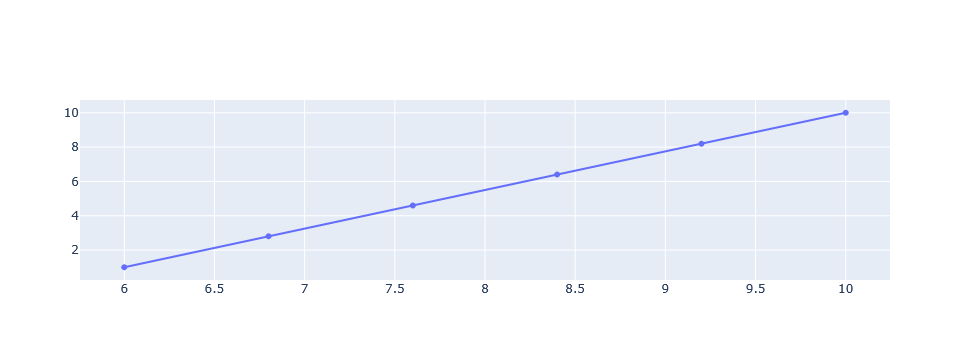

In [18]:
p0 = np.array([6, 1], dtype=np.float32)
p1 = np.array([10,10], dtype=np.float32)

N = 5
delta = 1.0 / N

sample_points = []
for t in range(0, N + 1):
    p_t = p0 * (1.0 - t * delta)  + (t * delta) * p1
    sample_points.append(p_t)
sample_points = np.array(sample_points)

fig = go.Figure(data=[
    go.Scatter(x=sample_points[:,0], y=sample_points[:,1],mode='markers+lines'),
])

fig.show() 

Pondremos nuestra cámara de perspectiva en (0,0) con focal_length X=5, mirando en la direction +X. Es decir, vamos a proyectar nuestros puntos a la recta X=5. 

En este sistema tenemos que el eje `w` de la cámara apunta a -X, y el eje `v` en Y. Por lo tanto proyectamos usando 
`y_s = y / x * focal_legth`

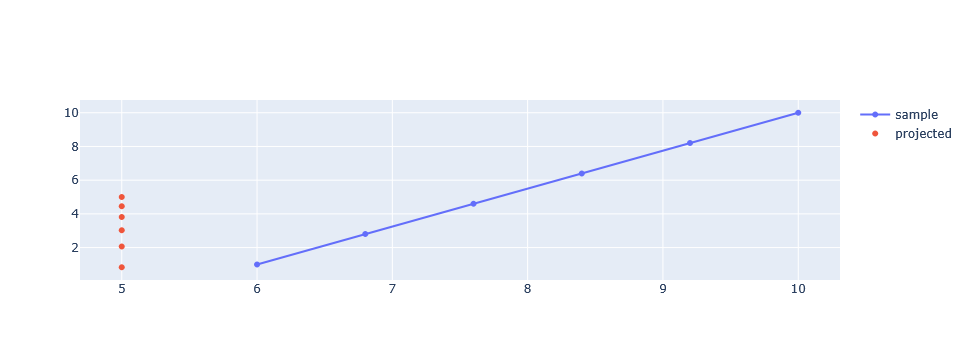

In [23]:
focal_length = 5.0

projected_points = np.empty_like(sample_points)
projected_points[:,0] = focal_length
projected_points[:,1] = sample_points[:,1] / sample_points[:,0] * focal_length

fig = go.Figure(data=[
    go.Scatter(x=sample_points[:,0], y=sample_points[:,1],mode='markers+lines', name='sample'),
    go.Scatter(x=projected_points[:,0], y=projected_points[:,1],mode='markers', name='projected'),
])

fig.show() 

Podemos visualizar las lineas de projeción (y así verificar visualmente nuestro codigo) lanzando lineas desde los sample points al cero de la cámara

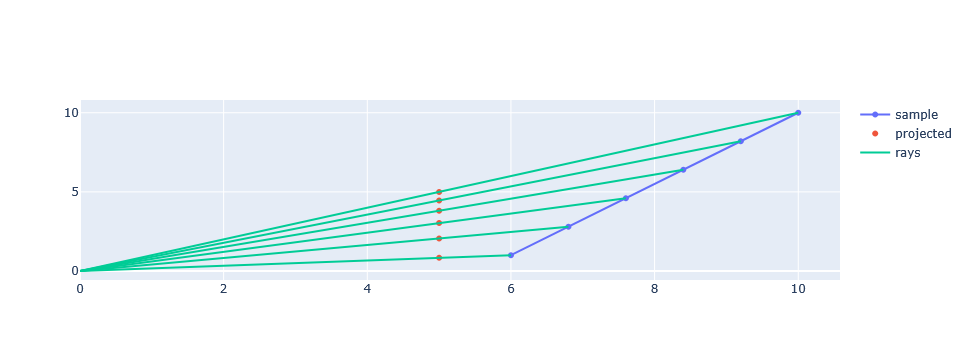

In [27]:
edges = np.zeros((3*(N+1), 2), dtype=np.float32)
edges[::3, :] = sample_points
edges[1::3, :] = 0 # i.e., camera position
edges[2::3, :] = None # separador de segmentos

fig = go.Figure(data=[
    go.Scatter(x=sample_points[:,0], y=sample_points[:,1],mode='markers+lines', name='sample'),
    go.Scatter(x=projected_points[:,0], y=projected_points[:,1],mode='markers', name='projected'),
    go.Scatter(x=edges[:,0], y=edges[:,1],mode='lines', name='rays'),

])

fig.show() 


La linea morada representa el plano de la imagen. Podemos imaginar los pixeles cómo puntos de esta linea que sampleamos

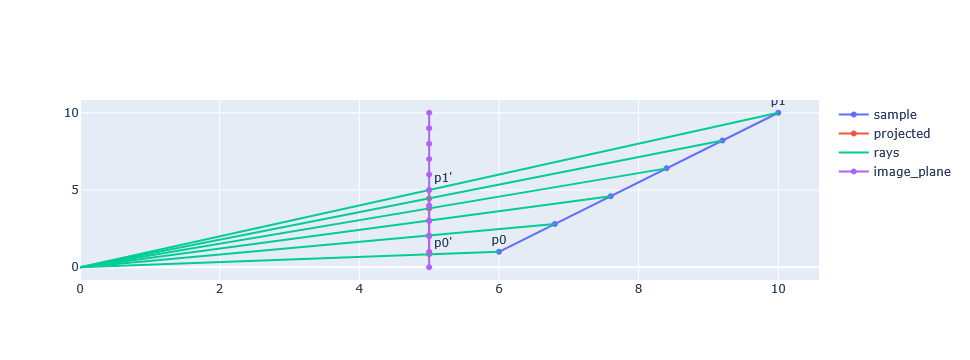

In [37]:
image_plane = np.array([ [focal_length, i] for i in range(0, 11)], dtype=np.float64)
sample_points_text = [""] * (N+1)
sample_points_text[0] = "p0"
sample_points_text[-1]  = "p1"

projected_points_text = [""] * (N+1)
projected_points_text[0] = "p0'"
projected_points_text[-1]  = "p1'"

fig = go.Figure(data=[
    go.Scatter(x=sample_points[:,0], y=sample_points[:,1], name='sample',
               text=sample_points_text, textposition='top center',  mode='markers+lines+text'),
    go.Scatter(x=projected_points[:,0], y=projected_points[:,1], name='projected', 
        text=projected_points_text, textposition='top right',  mode='markers+lines+text'),
    go.Scatter(x=edges[:,0], y=edges[:,1],mode='lines', name='rays'),
    go.Scatter(x=image_plane[:,0], y=image_plane[:,1],mode='lines+markers', name='image_plane'),

])

fig.show() 

Dado un atributo, e.j., profundidad definido en los puntos p0 y p1, cómo podemos calcular la profundidad de uno de nuestros "pixeles" (puntos morados)?

Cuando calculamos las coordenadas barycentricas, las obtenemos en coordenadas de la imagen. Es decir, con respecto a p0'y p1'.

In [40]:
# calculemos las "coordenadas barycentricas" para los puntos projectados. Utilizamos sólo la coordenada en Y que es la que varía
# 
# projected_points_i = (1 - r) * projected_points[0] + r * projected_points[-1]
# projected_points_i =  projected_points[0] + r (projected_points[-1] -  projected_points[0])
# (projected_points_i - projected_points[0]) / (projected_points[-1] -  projected_points[0]) = r

r = (projected_points[:,1] - projected_points[0, 1]) / (projected_points[-1, 1] - projected_points[0, 1])
r

array([0.        , 0.2941176 , 0.52631575, 0.7142858 , 0.86956525,
       1.        ], dtype=float32)

Podemos verificar que si usamos la version de interpolación simple (en coordenadas de la cámara) NO recuperamos los puntos originales. Los valores calzan para los extremos p0 y p1 pero no para los valores intermedios

i=0 interpolated=[6. 1.] original=[6. 1.]
i=1 interpolated=[7.1764703 3.6470585] original=[6.8 2.8]
i=2 interpolated=[8.105263  5.7368417] original=[7.6000004 4.6      ]
i=3 interpolated=[8.857143 7.428572] original=[8.4 6.4]
i=4 interpolated=[9.47826  8.826087] original=[9.2 8.2]
i=5 interpolated=[10. 10.] original=[10. 10.]


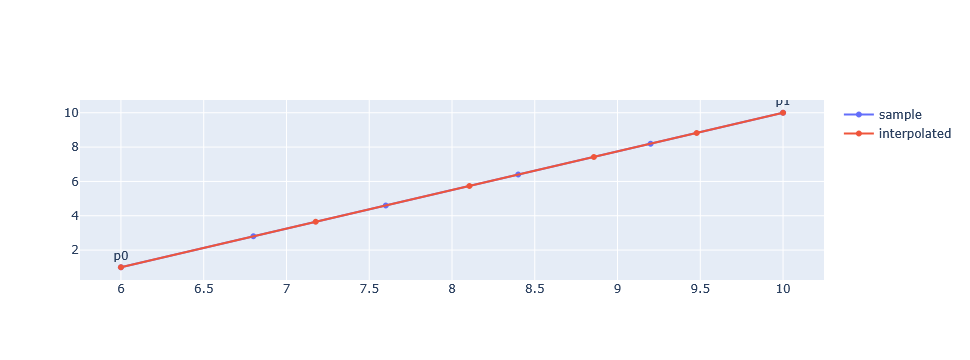

In [44]:
interpolated_points = []
for i in range(len(sample_points)):
    interpolated_pi = (1 - r[i]) * p0 + r[i] * p1 
    original_pi = sample_points[i]
    interpolated_points.append(interpolated_pi)
    print(f"i={i} interpolated={interpolated_pi} original={original_pi}")

interpolated_points = np.array(interpolated_points)
fig = go.Figure(data=[
    go.Scatter(x=sample_points[:,0], y=sample_points[:,1], name='sample',
               text=sample_points_text, textposition='top center',  mode='markers+lines+text'),
    go.Scatter(x=interpolated_points[:,0], y=interpolated_points[:,1], name='interpolated')
])

fig.show() 

Para correguir la interpolación debemos considerar la proyección que hicimos
`y_s = y / x * focal_legth`
y aplicar la misma proyección a las coordenadas barycentricas.

**Ejercicio**: Siguiendo las notas del curso, calcula los valores de A0 y A1 para arreglar la interpolación

i=0 interpolated=[6. 1.] original=[6. 1.]
i=1 interpolated=[7.1764703 3.6470585] original=[6.8 2.8]
i=2 interpolated=[8.105263  5.7368417] original=[7.6000004 4.6      ]
i=3 interpolated=[8.857143 7.428572] original=[8.4 6.4]
i=4 interpolated=[9.47826  8.826087] original=[9.2 8.2]
i=5 interpolated=[10. 10.] original=[10. 10.]


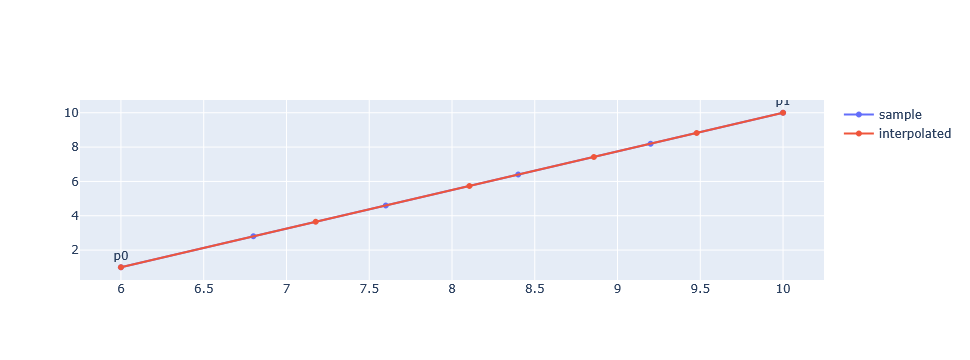

In [48]:
interpolated_points = []
for i in range(len(sample_points)):

    A0 = (1 - r[i]) 
    A1 = r[i] 
    s =  A0 + A1
    
    interpolated_pi = (A0 * p0 + A1 * p1)/s
    original_pi = sample_points[i]
    interpolated_points.append(interpolated_pi)
    print(f"i={i} interpolated={interpolated_pi} original={original_pi}")

interpolated_points = np.array(interpolated_points)
fig = go.Figure(data=[
    go.Scatter(x=sample_points[:,0], y=sample_points[:,1], name='sample',
               text=sample_points_text, textposition='top center',  mode='markers+lines+text'),
    go.Scatter(x=interpolated_points[:,0], y=interpolated_points[:,1], name='interpolated')
])

fig.show() 